# Modeling Variance Threshold - Random Forest - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective


Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedKFold,learning_curve
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
RANDOM_STATE = 42

rfc =  RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1)

xtrain_VT = pd.read_csv("xtrain_VT.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=rfc,X=xtrain_VT,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
df_results = pd.DataFrame(cv_results)

df_results

,fit_time,score_time,test_score,train_score
0,0.494804,0.046426,0.733849,1.0
1,0.487817,0.035661,0.754685,1.0
2,0.482622,0.036354,0.747148,1.0
3,0.507075,0.037113,0.746202,1.0
4,0.474229,0.037557,0.731886,1.0


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.7427540549249256


Le Random Forest avec ses hyperparamètres par défaut obtient un F1-macro moyen d’environ **0,743** en validation croisée. Les scores de validation sont relativement stables entre les folds.

Le F1-macro moyen d’entraînement atteint **1,000**, soit un écart d’environ **0,257** avec la validation. Le modèle présente donc un surapprentissage important.

Cette baseline constitue le point de référence avant optimisation. Le tuning cherchera à réduire cet écart sans dégrader la performance de validation.

## 3. Hyperparameter Tuning

In [3]:


settings_grid= {
    "max_depth":[5, 10, 15, 20],
    "min_samples_leaf":[2, 5, 10],
    "min_samples_split":[2, 5, 10],
    "max_features":["sqrt", 0.5],
}

grid_search = GridSearchCV(estimator=rfc,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_VT,
    ytrain,
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [4]:
best_i = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_i]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_i]
)

Best parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best validation F1: 0.747079042563102
Mean train F1: 0.9835340057960037
Std validation F1: 0.007969891187516929


La recherche d’hyperparamètres sélectionne `max_depth=20`, `max_features=0.5`, `min_samples_leaf=2` et `min_samples_split=2`.

Le F1-macro moyen de validation atteint **0,7471**, contre environ **0,7428** pour la baseline. Le F1-macro moyen d’entraînement diminue de **1,000 à 0,9835**.

L’amélioration de validation reste modeste, mais la régularisation réduit légèrement l’écart entraînement–validation. Le modèle conserve néanmoins un surapprentissage important.

L’écart-type du F1-macro de validation est d’environ **0,008**, ce qui indique une performance assez stable entre les folds.

## 4. Final Evaluation

### 4.1 Confusion Matrix

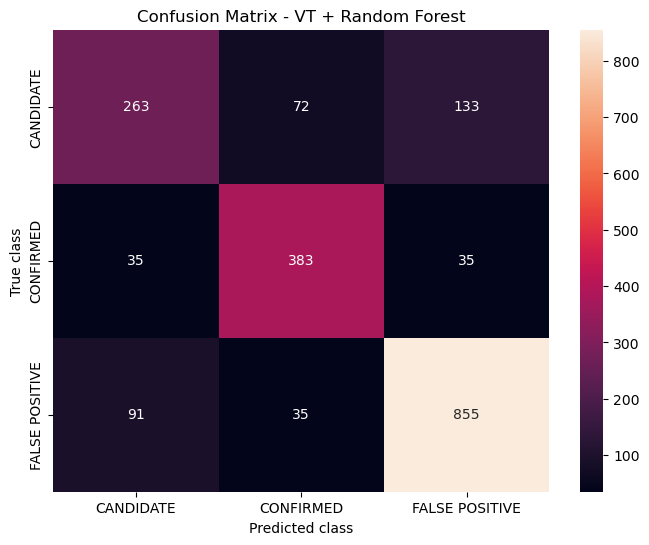

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_VT = pd.read_csv("xtest_VT.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_VT)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - VT + Random Forest")

plt.show();

Le Random Forest utilisant la sélection Variance Threshold fournit les meilleurs résultats parmi ces trois combinaisons.

Sur les **468** `CANDIDATE`, **263** sont correctement identifiés, contre **72** prédits `CONFIRMED` et **133** prédits `FALSE POSITIVE`. Parmi les **453** `CONFIRMED`, **383** sont correctement classés, et parmi les **981** `FALSE POSITIVE`, **855** sont correctement reconnus.

La classe `CANDIDATE` reste la plus difficile à distinguer, mais ce modèle réduit les erreurs par rapport aux deux autres combinaisons. Il obtient également de meilleures performances pour les classes `CONFIRMED` et `FALSE POSITIVE`.

### 4.2 Metrics


In [6]:
class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")


print(f"Accuracy : {round(accuracy*100,3)} %" )
print(f"Precision macro : {round(precision*100,3)} %" )
print(f"Recall macro : {round(recall*100,3)} %" )
print(f"F1 macro : {round(f1*100,3)} %")
print("============================================================================================")
print(f"Classification report :", class_report)

Accuracy : 78.917 %
Precision macro : 76.45 %
Recall macro : 75.967 %
F1 macro : 75.979 %
Classification report :                 precision    recall  f1-score   support

     CANDIDATE       0.68      0.56      0.61       468
     CONFIRMED       0.78      0.85      0.81       453
FALSE POSITIVE       0.84      0.87      0.85       981

      accuracy                           0.79      1902
     macro avg       0.76      0.76      0.76      1902
  weighted avg       0.78      0.79      0.78      1902



### 4.3 Learning Curve – Overfitting / Underfitting Analysis

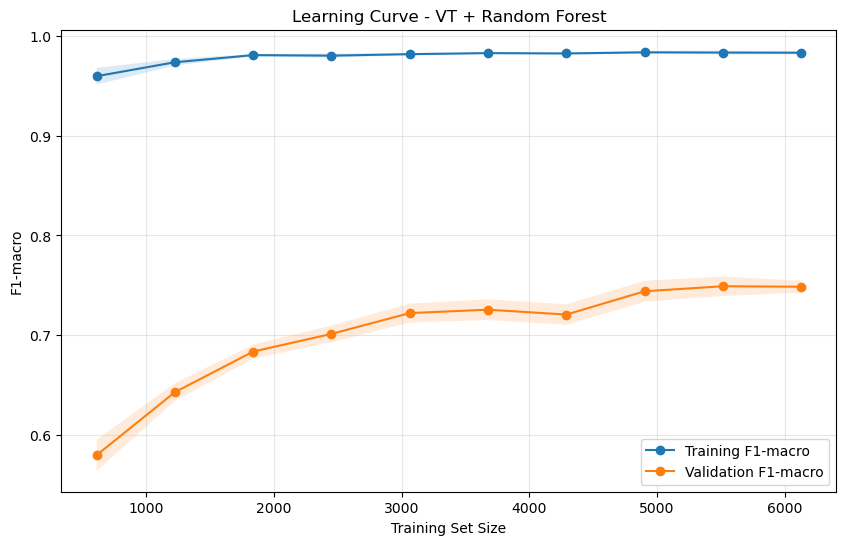

In [8]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=best_model,
    X=xtrain_VT,
    y=ytrain,
    cv=StratifiedKfold_cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training F1-macro"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation F1-macro"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Training Set Size")
plt.ylabel("F1-macro")
plt.title("Learning Curve - VT + Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show();

In [ ]:
final_train_score = train_mean[-1]
final_validation_score = validation_mean[-1]
generalization_gap = final_train_score - final_validation_score

print("Final training F1-macro:", round(final_train_score, 4))
print("Final validation F1-macro:", round(final_validation_score, 4))
print("Generalization gap:", round(generalization_gap, 4))

Final training F1-macro: 0.9776
Final validation F1-macro: 0.7405
Generalization gap: 0.2371


#### Interpretation

La courbe d’apprentissage confirme un écart persistant entre l’entraînement et la validation.

À la taille maximale du jeu d’entraînement, le F1-macro d’entraînement est d’environ **0,978**, contre **0,741** en validation, soit un écart de généralisation d’environ **0,237**.

Le Random Forest apprend donc très bien les données d’entraînement, mais généralise moins bien sur des observations non vues. Le modèle présente encore un surapprentissage.

Le score de validation continue toutefois à progresser avec la quantité de données d’entraînement, ce qui suggère que davantage de données pourrait encore améliorer la généralisation.

### 4.4 ROC and AUC 

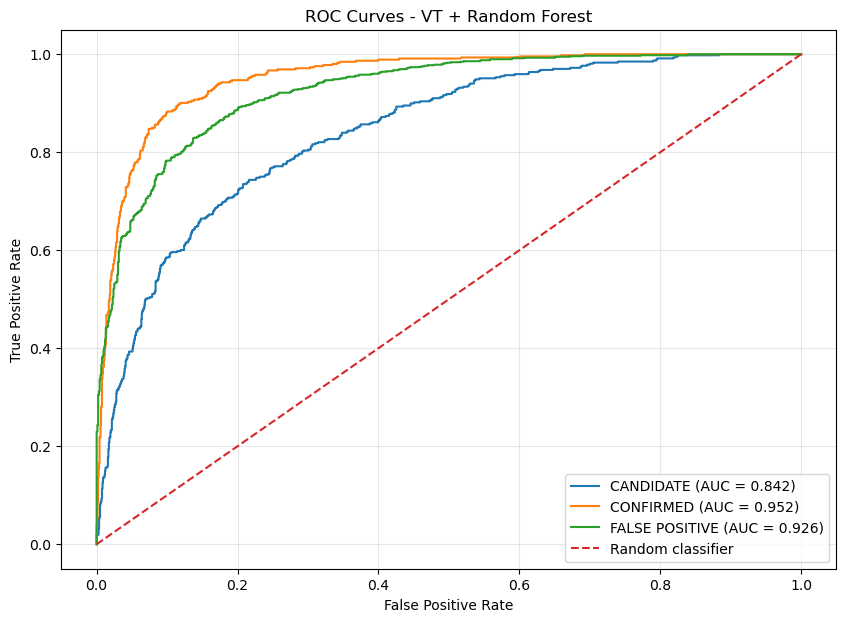

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
classes = best_model.classes_

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

y_proba = best_model.predict_proba(X_test_VT)

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_proba[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - VT + Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show();

In [ ]:
macro_roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro",
    labels=classes
)

print("Macro ROC-AUC (OvR):", round(macro_roc_auc, 4))

Macro ROC-AUC (OvR): 0.9068


#### Interprétation

Les courbes ROC montrent une bonne capacité globale de discrimination entre les trois classes, avec une **ROC-AUC macro OvR de 0,9068**.

La classe `CONFIRMED` obtient une AUC d’environ **0,952**, suivie de `FALSE POSITIVE` avec environ **0,926**. La classe `CANDIDATE` reste la plus difficile à distinguer, avec une AUC d’environ **0,842**.

La ROC-AUC est utilisée ici comme métrique complémentaire. Le F1-macro reste la métrique principale, car il accorde le même poids aux performances obtenues sur chacune des trois classes.

## 5. Model Limits

Cette combinaison obtient les meilleurs résultats des trois sur chacune des classes. Cela suggère que le maintien d’un ensemble relativement large de variables après Variance Threshold est bénéfique au Random Forest, qui peut exploiter des interactions entre plusieurs caractéristiques sans dépendre d’un seul arbre. Toutefois, la classe CANDIDATE reste la plus difficile à prédire, ce qui suggère qu’une partie de l’erreur pourrait provenir de l’ambiguïté intrinsèque de cette classe plutôt que d’un simple manque de capacité du modèle.